# Step 2 — 9 Zones, 4 Colors, and an XY-Ring Mixer on `tensornet`

**CUDA-Q QAOA GPU-Optimization Learning Path · notebook 2**

Notebooks 0-1 colored the 4 regions of Taiwan (16 qubits) with a plain `rx` mixer. Here we go to
the finer 9-zone partition (`helpers.ZONE_ORDER`) with 4 colors, which is `9 * 4 = 36` qubits.

That is far too many qubits for a dense statevector simulator: a 36-qubit statevector holds
`2**36` complex amplitudes, 8 bytes each, i.e. `2**36 * 8` bytes = about 550 GB — well beyond any
single GPU's memory. So instead of `nvidia` we use CUDA-Q's `tensornet` backend, which represents
the state as a tensor network and never forms the full statevector; the trade-off is that each
circuit evaluation now costs tens of seconds instead of milliseconds, so we must spend our
evaluation budget carefully.

We also swap the plain `rx` mixer for a smarter one: within each 4-qubit, one-hot-per-zone block
we start in an equal superposition over the 4 valid ("exactly one color on") basis states — a
*W state* — and mix only *inside* that one-hot subspace with an XY ring mixer built from `h`,
`rx`, `cx`/`x.ctrl` and `rz`. This keeps the search closer to valid colorings than a free-for-all
`rx` mixer would.

Deliberately, no `CUDAQ_*` environment variables are set in this notebook.

In [1]:
# cell 1 — build the 9-zone, 4-color QUBO and its spin Hamiltonian; print term counts.
import sys, time
import matplotlib.pyplot as plt
import helpers as hp
import cudaq

cudaq.set_target("tensornet", option="fp32")
cudaq.set_random_seed(1234)
print(f"CUDA-Q {cudaq.__version__.split()[2]}   Python {sys.version.split()[0]}")

taiwan = hp.load_map()
NODES = hp.ZONE_ORDER                # 9 zones
EDGES = taiwan["zone_edges"]
K = 4
A, B = 8.0, 1.0
N_ZONES = len(NODES)
N = N_ZONES * K                      # 9 * 4 = 36 qubits

coeffs, qubo_offset = hp.build_qubo(NODES, EDGES, K, A, B)
H, terms, offset = hp.qubo_to_spin(coeffs, qubo_offset)
zq, zc, zz1, zz2, zzc = hp.terms_to_lists(terms)

print(f"{N_ZONES} zones x {K} colors = {N} qubits")
print(f"spin Hamiltonian: {len(terms['z'])} Z terms + {len(terms['zz'])} ZZ terms, "
      f"constant offset {offset}")
print(f"zone adjacency edges: {len(EDGES)}")

CUDA-Q amd64-cu13-0.15.0   Python 3.12.3
9 zones x 4 colors = 36 qubits
spin Hamiltonian: 36 Z terms + 110 ZZ terms, constant offset 158.0
zone adjacency edges: 14


## A W-state mixer that stays inside the one-hot subspace

For each zone's 4 qubits we prepare `|1000>` with a single `x`, then spread that single excitation
into an equal superposition over `|1000>, |0100>, |0010>, |0001>` (a W state) using three
controlled-`ry` / controlled-`x` pairs with fixed angles `W_ANGLES`. That is the mixer's starting
point instead of `h(q)` on every qubit.

After the usual `rz`/`cx`-`rz`-`cx` cost layer (identical in shape to notebooks 0-1, just bigger),
the mixer itself is an **XY ring mixer**: for the 4 ring pairs `(0,1), (1,2), (2,3), (3,0)` inside
each zone's block, we apply an `XX` rotation (`h,h` / `cx` / `rz(2*beta)` / `cx` / `h,h`) followed
by a `YY` rotation (`rx(+pi/2),rx(+pi/2)` / `cx` / `rz(2*beta)` / `cx` / `rx(-pi/2),rx(-pi/2)`).
XY rotations conserve the number of `1`s in each block, so this mixer moves probability around
*within* the one-hot subspace rather than leaking out of it, unlike a plain `rx`. Only 1- and
2-qubit gates are used throughout.

In [2]:
# cell 2 — the xy_kernel: per-zone W-state prep, cost layer, XY ring mixer (p = 1).
W_ANGLES = [2.0943951023931953, 1.9106332362490186, 1.5707963267948966]
HALF_PI = 1.5707963267948966

@cudaq.kernel
def xy_kernel(n: int, n_zones: int, w_angles: list[float], zq: list[int], zc: list[float],
              zz1: list[int], zz2: list[int], zzc: list[float], gamma: float, beta: float):
    q = cudaq.qvector(n)
    for z in range(n_zones):                          # per-zone W-state preparation
        base = z * 4
        x(q[base])
        for k in range(3):
            ry.ctrl(w_angles[k], q[base + k], q[base + k + 1])
            x.ctrl(q[base + k + 1], q[base + k])
    for i in range(len(zq)):                          # cost layer: Z terms
        rz(2.0 * gamma * zc[i], q[zq[i]])
    for i in range(len(zz1)):                         # cost layer: ZZ terms
        x.ctrl(q[zz1[i]], q[zz2[i]])
        rz(2.0 * gamma * zzc[i], q[zz2[i]])
        x.ctrl(q[zz1[i]], q[zz2[i]])
    for z in range(n_zones):                          # XY ring mixer, per zone
        base = z * 4
        for k in range(4):
            qa = base + k
            qb = base + (k + 1) % 4
            h(q[qa])                                  # XX(2*beta)
            h(q[qb])
            x.ctrl(q[qa], q[qb])
            rz(2.0 * beta, q[qb])
            x.ctrl(q[qa], q[qb])
            h(q[qa])
            h(q[qb])
            rx(1.5707963267948966, q[qa])             # YY(2*beta)
            rx(1.5707963267948966, q[qb])
            x.ctrl(q[qa], q[qb])
            rz(2.0 * beta, q[qb])
            x.ctrl(q[qa], q[qb])
            rx(-1.5707963267948966, q[qa])
            rx(-1.5707963267948966, q[qb])

def energy(params):
    gamma = params[0]
    beta = params[1]
    return cudaq.observe(xy_kernel, H, N, N_ZONES, W_ANGLES, zq, zc, zz1, zz2, zzc,
                         gamma, beta).expectation() + offset

print("xy_kernel built: W-state prep + cost layer + XY ring mixer, 1- and 2-qubit gates only.")

xy_kernel built: W-state prep + cost layer + XY ring mixer, 1- and 2-qubit gates only.


## Optimize on `tensornet` — a small, timed budget

Each `energy()` call now runs a 36-qubit tensor-network contraction, costing tens of seconds, so
we keep the evaluation budget tiny: `NelderMead` with `max_iterations = 5`, starting from
`gamma = 0.1, beta = 0.1`, exactly as in notebook 1. We time the whole optimization once and report
seconds per evaluation as `total time / 5` — no other `energy()` calls are made anywhere in this
notebook.

In [3]:
# cell 3 — optimize with Nelder-Mead, 5 evaluations total, timed.
num_iterations = 5
START = [0.1, 0.1]

optimizer = cudaq.optimizers.NelderMead()
optimizer.max_iterations = num_iterations
optimizer.initial_parameters = START

t0 = time.perf_counter()
best_energy, best_angles = optimizer.optimize(dimensions=2, function=energy)
opt_seconds = time.perf_counter() - t0
seconds_per_eval = opt_seconds / num_iterations

print(f"Nelder-Mead (tensornet): best energy {best_energy:.6f} at "
      f"gamma = {best_angles[0]:.6f}, beta = {best_angles[1]:.6f}")
print(f"{opt_seconds:.3f} s total for {num_iterations} evaluations "
      f"= {seconds_per_eval:.3f} s/evaluation")

Nelder-Mead (tensornet): best energy 3.500458 at gamma = -1.470796, beta = 3.141593
409.860 s total for 5 evaluations = 81.972 s/evaluation


## Sample the optimized circuit

With `best_angles` fixed, we sample the circuit `SHOTS = 2000` times — small, since each shot on
`tensornet` also costs real wall-clock time — and decode every bitstring back into a zone coloring
with `helpers.summarize_samples`. The one check in this notebook: the best sampled bitstring is a
valid coloring.

In [4]:
# cell 4 — sample SHOTS = 2000 shots at the best angles found, summarize, and check validity.
SHOTS = 2000

t0 = time.perf_counter()
shots = cudaq.sample(xy_kernel, N, N_ZONES, W_ANGLES, zq, zc, zz1, zz2, zzc,
                     best_angles[0], best_angles[1], shots_count=SHOTS)
sample_seconds = time.perf_counter() - t0
seconds_per_shot = sample_seconds / SHOTS

counts = {}
for bitstring, times_seen in shots.items():
    counts[bitstring] = times_seen

result = hp.summarize_samples(counts, NODES, K, EDGES, coeffs, qubo_offset)

# THE check of this notebook: the sampled answer really is a valid coloring.
assert result["best"] is not None and hp.is_valid(result["best"], NODES, K, EDGES)
print("check passed: the best sampled bitstring is a valid coloring")
print(f"{sample_seconds:.3f} s total for {SHOTS} shots = {seconds_per_shot:.6f} s/shot")

valid colorings among raw samples: 16 / 2,000 shots = 0.8000%  (16 distinct bitstrings)
best valid coloring: '100001000010010010000010000101000001' (sampled 1 times, energy 0.0)
   Taipei=0, Keelung=1, Taoyuan-Hsinchu-Miaoli=2, Yilan=1, Taichung-Changhua-Nantou=0, Yunlin-Chiayi=2, Tainan=3, South=1, East=3
check passed: the best sampled bitstring is a valid coloring
25.353 s total for 2000 shots = 0.012677 s/shot


## Draw the 9-zone coloring

Finally, paint every county by its zone's decoded color, draw the 9-zone adjacency graph over the
map with `helpers.group_positions(taiwan, "zone")`, and add the color legend. We also report the
timing summary (seconds per evaluation, seconds per shot) and the optimized angles `theta*`.

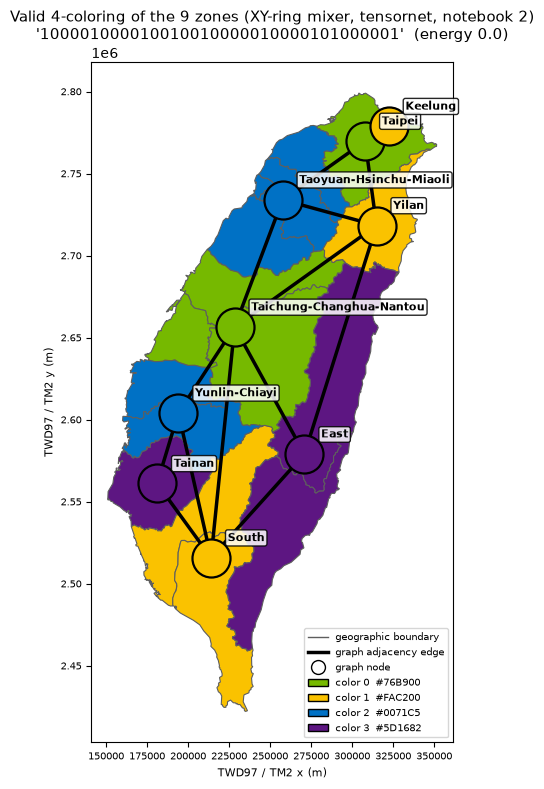

SUMMARY
------------------------------------------------------------------
problem             : 9 zones x 4 colors = 36 qubits, A = 8.0, B = 1.0
backend              : tensornet (fp32), no CUDAQ_* env vars set
best energy          : 3.500458
theta* (gamma, beta) : (-1.470796, 3.141593)
time per evaluation  : 81.972 s  (optimization, 5 evaluations)
time per shot        : 0.012677 s  (sampling, 2000 shots)
valid-sample rate    : 0.8000% of 2000 shots
------------------------------------------------------------------


In [5]:
# cell 5 — draw the zone coloring, then report timings and the optimized angles.
best_coloring = result["assignment"]
unit_colors = {}
for name, county in taiwan["counties"].items():
    unit_colors[name] = hp.PALETTE[best_coloring[county["zone"]]]
node_colors = {}
for zone in hp.ZONE_ORDER:
    node_colors[zone] = hp.PALETTE[best_coloring[zone]]

fig, ax = hp.plot_map(taiwan, unit_colors=unit_colors,
                      node_pos=hp.group_positions(taiwan, "zone"), edges=EDGES,
                      node_colors=node_colors, unit_labels=False, color_legend=True,
                      title="Valid 4-coloring of the 9 zones (XY-ring mixer, tensornet, notebook 2)\n"
                            f"'{result['best']}'  (energy {result['best_energy']:.1f})")
plt.show()

print("SUMMARY")
print("-" * 66)
print(f"problem             : {N_ZONES} zones x {K} colors = {N} qubits, A = {A}, B = {B}")
print(f"backend              : tensornet (fp32), no CUDAQ_* env vars set")
print(f"best energy          : {best_energy:.6f}")
print(f"theta* (gamma, beta) : ({best_angles[0]:.6f}, {best_angles[1]:.6f})")
print(f"time per evaluation  : {seconds_per_eval:.3f} s  (optimization, {num_iterations} evaluations)")
print(f"time per shot        : {seconds_per_shot:.6f} s  (sampling, {SHOTS} shots)")
print(f"valid-sample rate    : {result['valid_rate']:.4%} of {SHOTS} shots")
print("-" * 66)